In [ ]:
import pandas as pd
from tnwater import plot_id
import seaborn as sns
import matplotlib.pyplot as plt

# read in data
df = pd.read_csv('../../data/cleaned_data.csv')



# SPENCER!!! - check and see if any of the data we picked up from an id/event included different depth levels.
# If we did, we need to decide what to do about that. My inital reaction is to find out what depth the collect
# the data where they're not doing a depth profile and slice the samples to match the other depths.repr

# ...you beautiful genius

In [3]:

# rename some of the columns so the names are not as long

# Modify the original DataFrame directly
df.rename(columns={'inorganic_nitrogen_(nitrate_and_nitrite)_total': 'no3_no2',
            'chlorophyll_a_total': 'chla',
            'phosphorus_total': 'tp',
            'total_suspended_solids_suspended': 'tss'}, inplace=True)


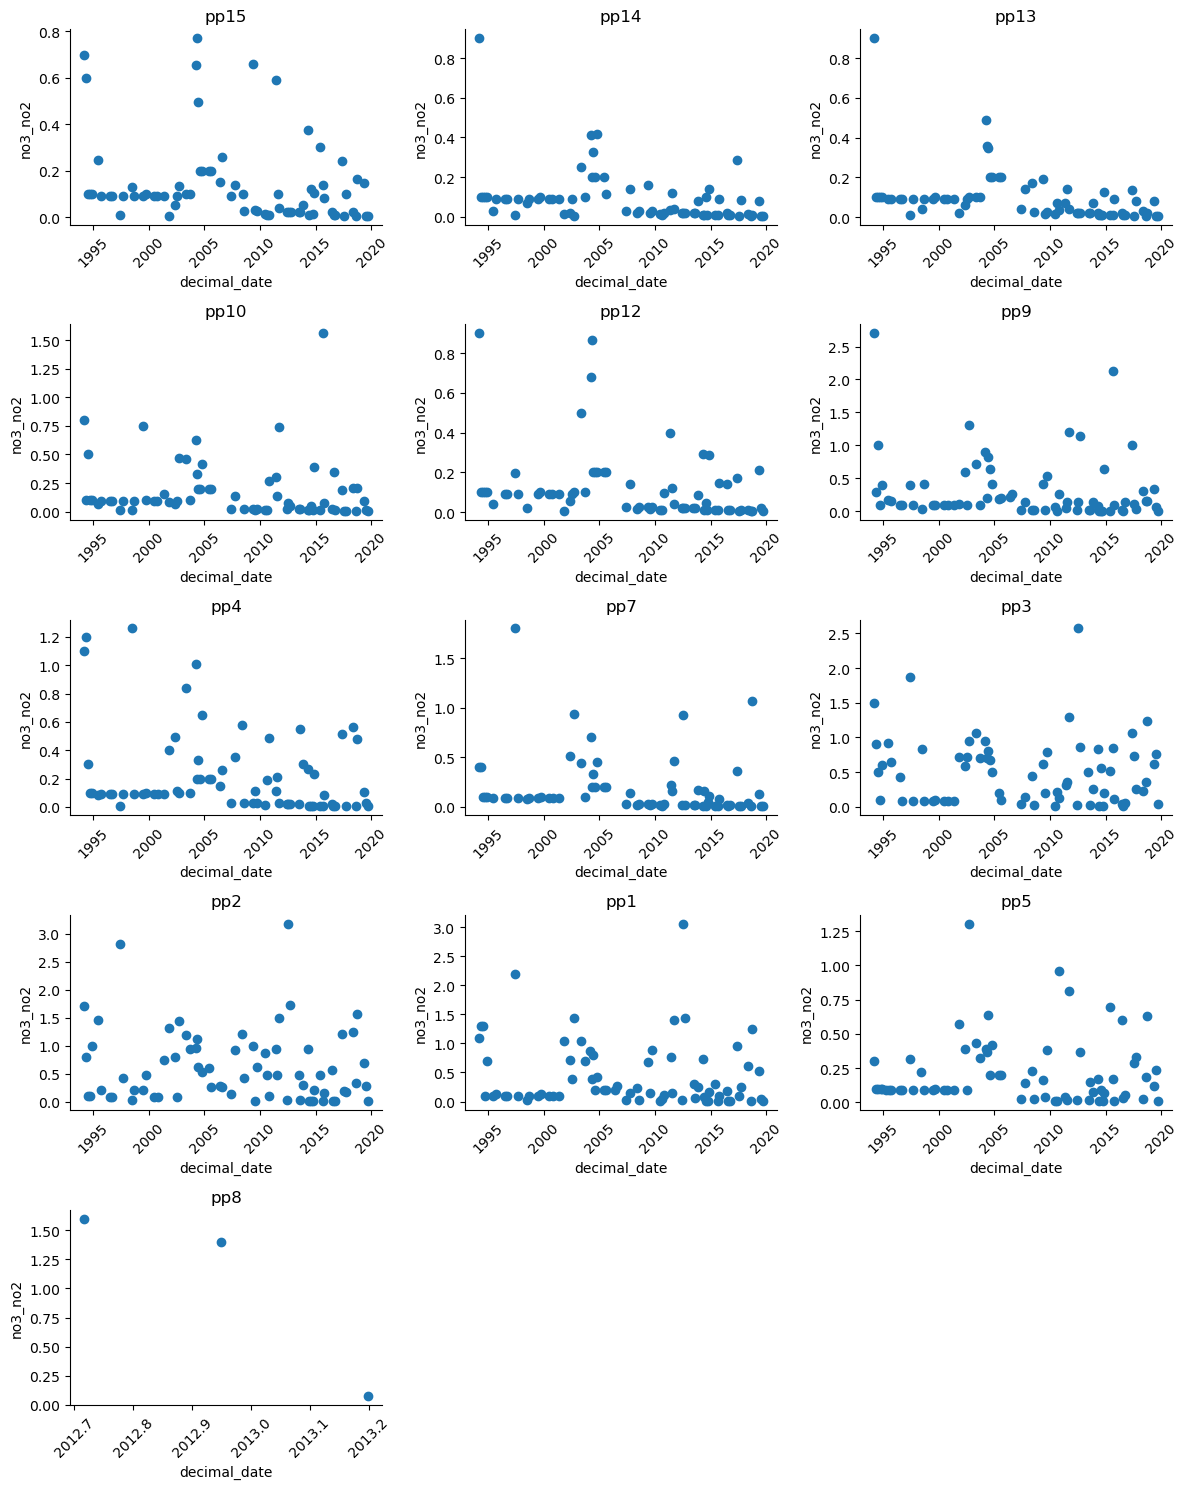

In [16]:
plot_id(df, var='no3_no2', site_col='site', site_name='percy_priest',
        x_col='decimal_date', y_col='no3_no2', kind='scatter')

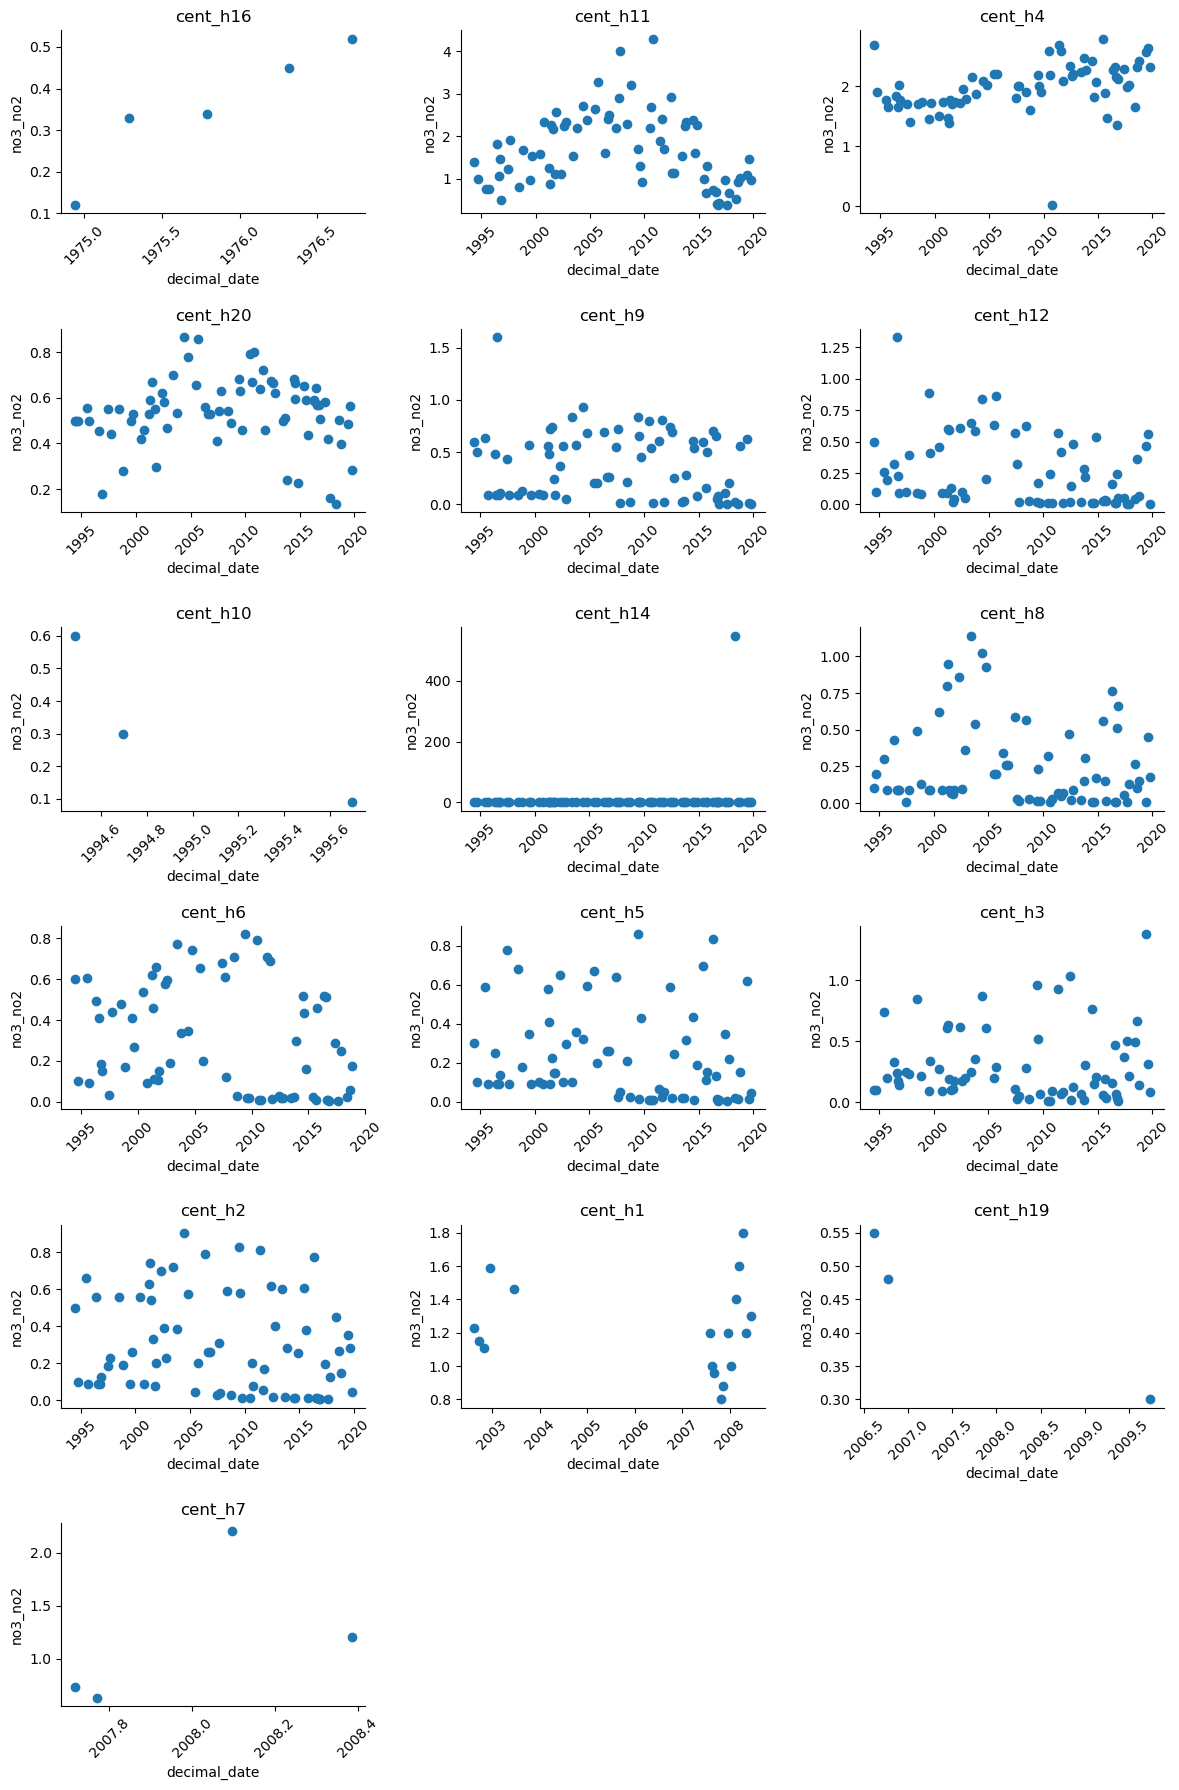

In [17]:
plot_id(df, var='no3_no2', site_col='site', site_name='center_hill',
        x_col='decimal_date', y_col='no3_no2', kind='scatter')

In [18]:
# Returns a Series with group labels as the index
df.groupby('id').size()

id
cent_h1      17
cent_h10      3
cent_h11     74
cent_h12     72
cent_h13      1
cent_h14     84
cent_h15      7
cent_h16      5
cent_h17      9
cent_h18      9
cent_h19      4
cent_h2      75
cent_h20    101
cent_h3      72
cent_h4      72
cent_h5      74
cent_h6      69
cent_h7       4
cent_h8      75
cent_h9      75
dh1          64
dh10          1
dh11          1
dh12          1
dh13          1
dh14          1
dh15          1
dh16         70
dh17         70
dh18          1
dh2           1
dh3           1
dh4           1
dh5          68
dh6          71
dh7           1
dh8          70
dh9           1
pp1          72
pp10         68
pp11          1
pp12         69
pp13         70
pp14         70
pp15         72
pp16          2
pp2          71
pp3          70
pp4          72
pp5          71
pp6           4
pp7          69
pp8           3
pp9          72
dtype: int64

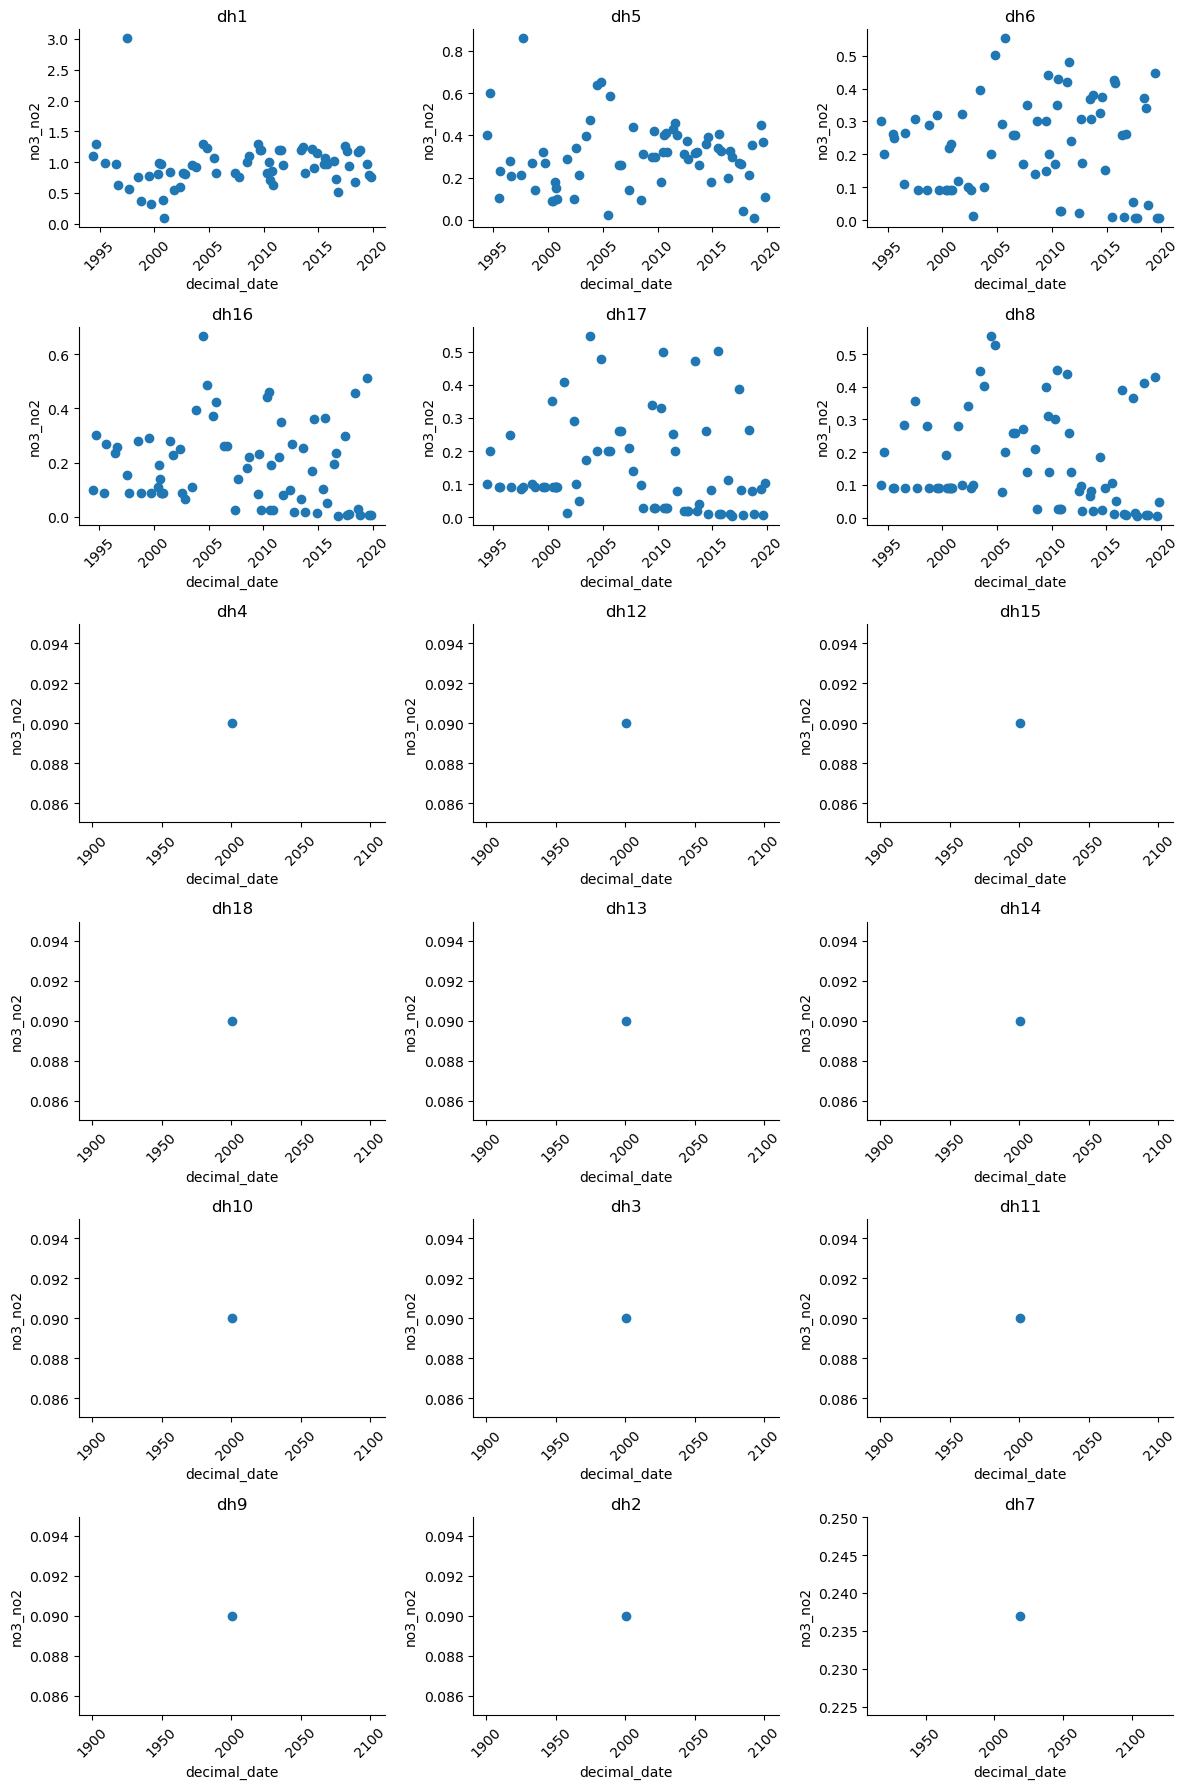

In [19]:
plot_id(df, var='no3_no2', site_col='site', site_name='dale_hollow',
        x_col='decimal_date', y_col='no3_no2', kind='scatter')

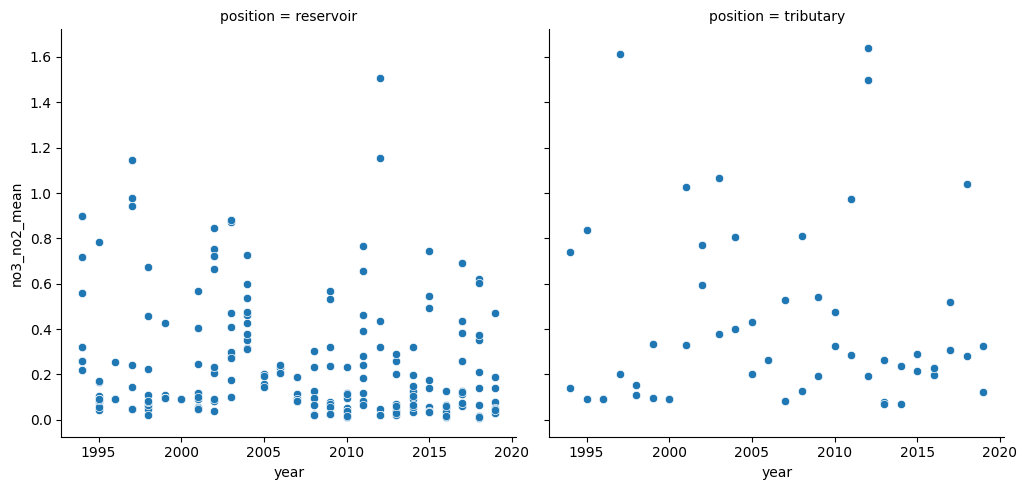

In [7]:
(df[df['site'] == 'percy_priest']
    .groupby(['id', 'position', 'year'])['no3_no2']
    .agg(no3_no2_mean='mean')
    .reset_index()
    .pipe(lambda d: sns.relplot(
        data=d,
        x='year',
        y='no3_no2_mean',
        col='position',
        col_wrap=4   # 👈 controls number of columns
    ))
)

plt.show()

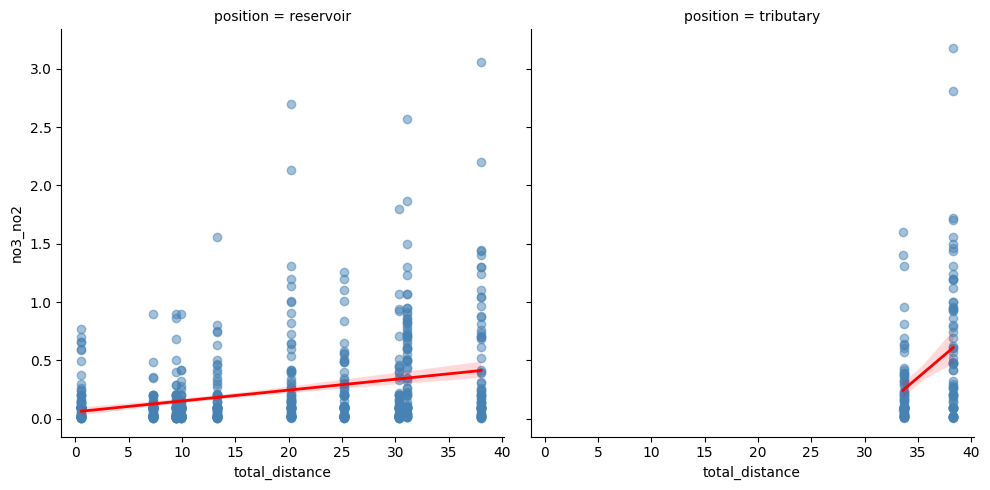

In [12]:
(df[df['site'] == 'percy_priest']
    .pipe(lambda d: sns.lmplot(
        data=d, x='total_distance', 
        y='no3_no2',
        col='position',
        scatter=True,       # show points too
        ci=95,               # confidence interval, like geom_smooth's se=TRUE
        line_kws={'color': 'red', 'linewidth': 2},       # regression line  - control the line color, linesize etc.
        scatter_kws={'color': 'steelblue', 'alpha': 0.5} # scatter points
    ))

)


In [15]:
import pingouin as pg
 
reservior_positions_only = df[df['position'] == 'reservoir']

pg.pairwise_corr(reservior_positions_only, columns=['no3_no2', 'total_distance'], method='pearson')

,X,Y,method,alternative,n,r,CI95,p_unc,BF10,power
0,no3_no2,total_distance,pearson,two-sided,1575,-0.036673,"[-0.09, 0.01]",0.145744,0.091,0.307124


In [ ]:
tributary_positions_only = df[df['position'] == 'tributary']

pg.pairwise_corr(tributary_positions_only, columns=['no3_no2', 'total_distance'], method='pearson')

# wow nutrient content in tribs is really correlated with distance total distance to the dam

,X,Y,method,alternative,n,r,CI95,p_unc,BF10,power
0,no3_no2,total_distance,pearson,two-sided,371,0.563711,"[0.49, 0.63]",1.678168e-32,1.943e+29,1.0


In [5]:
a = (df[df['site'] == 'percy_priest']
    .groupby(['id', 'year'])['no3_no2']
    .agg('mean')
    .reset_index())

In [8]:
df.columns

Index(['date_time', 'site', 'id', 'position', 'year', 'month', 'decimal_date',
       'latitude', 'longitude', 'distance_from_centerline_km',
       'total_distance', 'ammonia_total', 'ammonium_total', 'chla',
       'chlorophyll_b_fixed', 'chlorophyll_c_fixed',
       'dissolved_oxygen_(do)_dissolved', 'no3_no2', 'kjeldahl_nitrogen_total',
       'nitrate_total', 'nitrite_total', 'nitrogen_total',
       'organic_nitrogen_total', 'organic_phosphorus_total',
       'orthophosphate_dissolved', 'orthophosphate_total',
       'phosphorus_dissolved', 'tp', 'tss', 'turbidity_total', 'ph_total'],
      dtype='object')